# Option Pricing Engine

## Introduction

Option pricing models aim to determine the fair value of financial derivatives whose payoffs depend on an underlying asset such as a stock. Under the principle of no-arbitrage, options can be valued using risk-neutral pricing, where future payoffs are evaluated under the risk-neutral measure and discounted at the risk-free rate.

For the Black-Scholes and Monte Carlo models used in this notebook, stock prices are assumed to follow a stochastic process called Geometric Brownian Motion (GBM):

$$
dS_t = r S_t \, dt + \sigma S_t \, dW_t,
$$

where $S_t$ is the stock price at time $t$, $r$ is the risk-free interest rate, $\sigma$ is the volatility, and $W_t$ is a standard Brownian motion.

The binomial tree, Black-Scholes model and Monte Carlo simulation provide different approaches to option pricing under this risk-neutral framework.

In [1]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from option_pricing.options import VanillaOption, BarrierOption
from option_pricing.black_scholes import BlackScholesPricer
from option_pricing.binomial import BinomialPricer
from option_pricing.monte_carlo import MonteCarloPricer, BarrierMonteCarloPricer

## Historical Volatility Estimation

Volatility and the spot price are estimated from one year of historical data for Apple (AAPL), chosen as an example underlying asset to ensure realistic parameter values. A fixed one-year time window is used to ensure reproducibility.

In [2]:
# retrieve historical data
apple = yf.Ticker("AAPL")
data = apple.history(start="2024-10-01", end="2025-10-01")
close_prices = data["Close"].copy()
spot = close_prices.iloc[-1]

# compute historical volatility
log_returns = np.log(close_prices).diff().dropna()
volatility_daily = log_returns.std(ddof=1)
volatility = volatility_daily * np.sqrt(252)

print(f'Spot price: {spot:.2f}')
print(f'Volatility: {volatility:.2f}')

Spot price: 253.69
Volatility: 0.32


The remaining option parameters are fixed for the analysis. A one-year at-the-money option is considered, with the strike set equal to the estimated spot price and a risk-free rate of 5%.

In [3]:
strike = spot
rate = 0.05
maturity = 1

## Binomial Tree Model

The binomial tree model represents the stock price over a series of discrete time steps. At each step, the stock price can move up by a factor $u$ or down by a factor $d$:

$$
u = e^{\sigma\sqrt{\Delta t}}, \qquad d = \frac{1}{u}.
$$

The risk-neutral probability of an upward move is

$$
p = \frac{e^{r\Delta t} - d}{u-d}.
$$

The option price is calculated by working backwards through the tree and discounting the expected value at each node. For American options, the value at each node is the greater of the continuation value and the value from immediate exercise.

A European call option is first priced using a 500-step binomial tree.


In [4]:
european_call = VanillaOption(
    spot=spot,
    strike=strike,
    maturity=maturity,
    rate=rate,
    volatility=volatility,
    option_type="call",
)

binomial_pricer = BinomialPricer(european_call, steps=500)

binomial_call_price = binomial_pricer.price()

print(f"Binomial European Call: {binomial_call_price:.2f}")

Binomial European Call: 38.20


The binomial model can also price American options by considering early exercise at each node. The prices of otherwise equivalent European and American put options are compared below.

In [5]:
european_put = VanillaOption(
    spot=spot,
    strike=strike,
    maturity=maturity,
    rate=rate,
    volatility=volatility,
    option_type="put",
)

american_put = VanillaOption(
    spot=spot,
    strike=strike,
    maturity=maturity,
    rate=rate,
    volatility=volatility,
    option_type="put",
    exercise_style="american",
)

european_put_price = BinomialPricer(european_put, steps=500).price()
american_put_price = BinomialPricer(american_put, steps=500).price()

print(f"European Put: {european_put_price:.2f}")
print(f"American Put: {american_put_price:.2f}")

European Put: 25.83
American Put: 27.15


The American put is worth at least as much as the equivalent European put because the holder has the additional right to exercise before maturity.

## Black-Scholes Model

The Black-Scholes model provides a closed-form analytical solution for European option prices under the GBM assumptions. For a European call option, the price $C_0$ is

$$
C_0 = S_0 N(d_1) - K e^{-rT} N(d_2),
$$

where

$$
d_1 = \frac{\ln(S_0/K) + (r + \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}},
\qquad
d_2 = d_1 - \sigma\sqrt{T},
$$

and $N(x)$ is the standard normal cumulative distribution function.

In [6]:
bs_pricer = BlackScholesPricer(european_call)

black_scholes_call_price = bs_pricer.price()

print(f"Black-Scholes European Call: {black_scholes_call_price:.2f}")

Black-Scholes European Call: 38.22


The Black-Scholes price provides a closed-form benchmark against which the numerical binomial and Monte Carlo estimates can be compared.

### Binomial Convergence

For European options, the binomial price converges towards the Black-Scholes value as the number of time steps increases, as the discrete stock price process increasingly approximates the continuous-time process assumed by Black-Scholes.

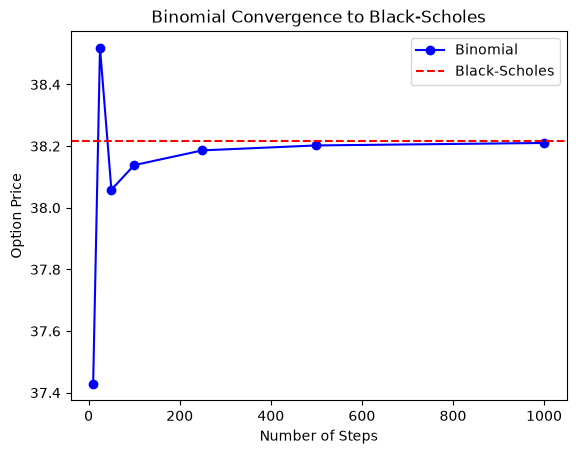

In [7]:
step_counts = [10, 25, 50, 100, 250, 500, 1000]

binomial_prices = [BinomialPricer(european_call, steps=steps).price() for steps in step_counts]

plt.plot(step_counts, binomial_prices, marker="o", label="Binomial", color="b")
plt.axhline(black_scholes_call_price, linestyle="--", label="Black-Scholes", color="r")
plt.xlabel("Number of Steps")
plt.ylabel("Option Price")
plt.title("Binomial Convergence to Black-Scholes")
plt.legend()
plt.show()

The binomial estimate initially oscillates around the Black-Scholes benchmark, with the pricing error decreasing as the number of steps increases.

## Monte Carlo Simulation

Monte Carlo simulation estimates option prices by simulating many possible future stock prices and averaging the discounted payoffs across all simulations. For a European option, whose payoff depends only on the terminal stock price, $N$ terminal prices are simulated directly from the GBM solution:

$$
S_T = S_0 \exp \left(\left(r-\frac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}\,Z\right), \qquad Z \sim N(0,1),
$$

where $Z$ is a standard normal random variable.

For a European call option, whose payoff depends only on the terminal price $S_T$, the price $C_0$ is estimated by

$$
C_0 \approx e^{-rT} \cdot \frac{1}{N} \sum_{i=1}^N \max(S_T^{(i)} - K, 0).
$$

The call price is computed using the same parameters as the Black-Scholes benchmark, with $N=1000$ simulations.

In [8]:
mc_pricer = MonteCarloPricer(european_call, seed=42)

monte_carlo_call_price, standard_error = mc_pricer.price(num_simulations=1000)

print(f"Black-Scholes Benchmark: {black_scholes_call_price:.2f}")
print(f"Monte Carlo (N=1000):    {monte_carlo_call_price:.2f}")
print(f"Standard Error:          {standard_error:.4f}")

Black-Scholes Benchmark: 38.22
Monte Carlo (N=1000):    35.84
Standard Error:          1.8725


### Convergence to Black-Scholes

The Monte Carlo estimate differs slightly from the Black-Scholes benchmark because it relies on a finite number of simulations $N$, introducing random sampling error. As $N$ increases, the Monte Carlo price converges to the closed-form Black-Scholes solution in accordance with the Law of Large Numbers (LLN). This convergence behaviour is illustrated in the plot below.

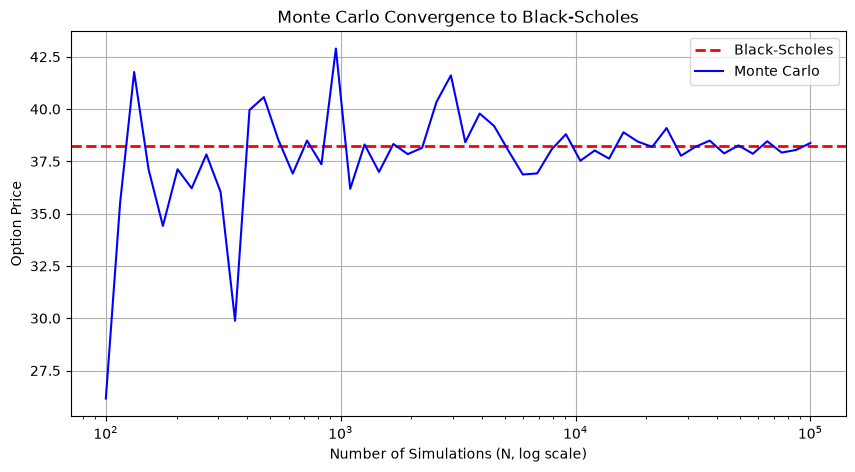

In [9]:
simulation_counts = np.logspace(2, 5, 50, dtype=int)

monte_carlo_prices = []
standard_errors = []

mc_convergence_pricer = MonteCarloPricer(european_call, seed=42)

for n in simulation_counts:
    price, se = mc_convergence_pricer.price(n)
    monte_carlo_prices.append(price)
    standard_errors.append(se)

plt.figure(figsize=(10, 5))

plt.axhline(black_scholes_call_price, linestyle="--", linewidth=2, color="r", label="Black-Scholes")
plt.plot(simulation_counts, monte_carlo_prices, color="b", label="Monte Carlo")

plt.xscale("log")
plt.xlabel("Number of Simulations (N, log scale)")
plt.ylabel("Option Price")
plt.title("Monte Carlo Convergence to Black-Scholes")

plt.grid()
plt.legend()
plt.show()

The logarithmic scale highlights the greater variability of the Monte Carlo estimates at smaller $N$, reflecting higher random sampling error. This variability is quantified by the standard error (SE):

$$
SE = \frac{\hat\sigma}{\sqrt{N}},
$$

where $\hat\sigma$ is the sample standard deviation of the discounted payoffs.

The plot below shows the standard error (SE) of the Monte Carlo price estimates across the same range of $N$ values used in the convergence plot.

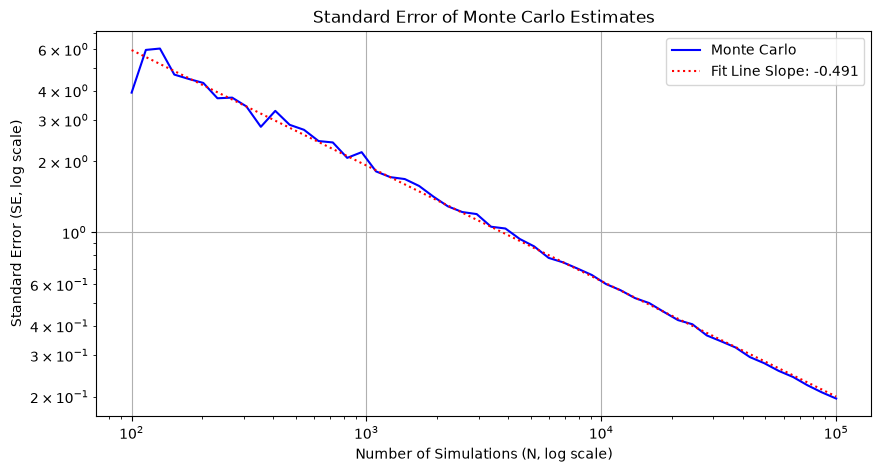

In [10]:
plt.figure(figsize=(10, 5))

plt.loglog(simulation_counts, standard_errors, color="b", label="Monte Carlo")
plt.xlabel("Number of Simulations (N, log scale)")
plt.ylabel("Standard Error (SE, log scale)")
plt.title("Standard Error of Monte Carlo Estimates")

coeffs = np.polyfit(np.log(simulation_counts), np.log(standard_errors), 1)
fit_line = np.exp(coeffs[1]) * simulation_counts ** coeffs[0]
plt.loglog(simulation_counts, fit_line, ":", color="r", label=f"Fit Line Slope: {coeffs[0]:.3f}")

plt.grid()
plt.legend()
plt.show()

The log–log plot shows that the standard error decreases linearly with $N$ on a logarithmic scale, with a slope of approximately $-\frac{1}{2}$. This is consistent with the theoretical convergence rate $SE \propto 1/\sqrt{N}$.

The final Monte Carlo price estimate from the convergence plot ($N=100000$) is shown alongside the earlier result for $N=1000$ to highlight the increase in accuracy.

In [11]:
print(f"Black-Scholes Benchmark:    {black_scholes_call_price:.2f}")
print(f"Monte Carlo (N=1000):       {monte_carlo_call_price:.2f}")
print(f"Monte Carlo (N=100000):     {monte_carlo_prices[-1]:.2f}")

Black-Scholes Benchmark:    38.22
Monte Carlo (N=1000):       35.84
Monte Carlo (N=100000):     38.38


### Variance Reduction: Antithetic Variates

Monte Carlo accuracy improves with more simulations $N$ but this also increases computational cost. The antithetic variates method is a form of variance reduction that increases precision without increasing $N$ by exploiting symmetry in the random draws $Z$. Each draw $Z$ is paired with its opposite $-Z$, producing negatively correlated payoffs, which when averaged, reduce the variance of the estimator.

The standard error (SE) is compared between the standard Monte Carlo and antithetic versions across a range of $N$ values to illustrate the reduction in variance.

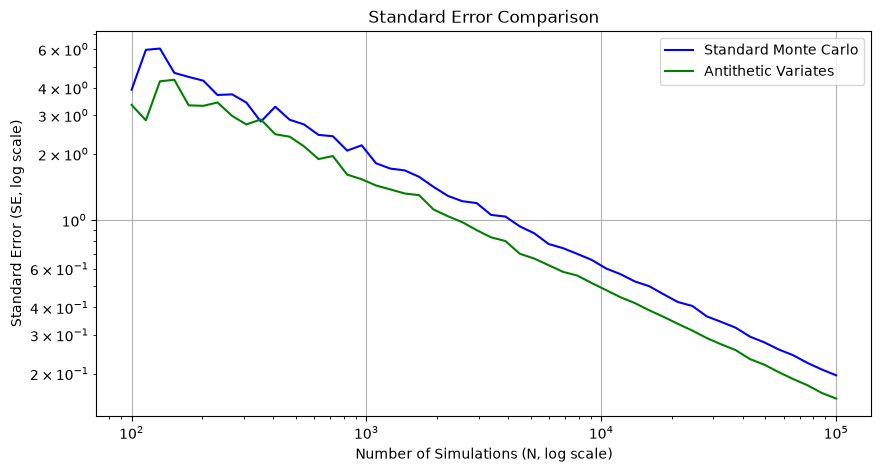

In [12]:
antithetic_errors = []

mc_antithetic_pricer = MonteCarloPricer(european_call, seed=42)

for n in simulation_counts:
    _, se = mc_antithetic_pricer.price_antithetic(n)
    antithetic_errors.append(se)

plt.figure(figsize=(10, 5))

plt.loglog(simulation_counts, standard_errors, color="b", label="Standard Monte Carlo")
plt.loglog(simulation_counts, antithetic_errors, color="g", label="Antithetic Variates")

plt.xlabel("Number of Simulations (N, log scale)")
plt.ylabel("Standard Error (SE, log scale)")
plt.title("Standard Error Comparison")

plt.grid()
plt.legend()
plt.show()

The antithetic variates method consistently produces lower standard error for the same number of simulations $N$, demonstrating its effectiveness in reducing variance.

### Exotic Options: Barrier Option

Monte Carlo simulation can also be used to price path-dependent exotic options by simulating the stock price over multiple time steps. A barrier option is path-dependent because its payoff depends not only on the terminal stock price, but also on whether the stock price reaches a specified barrier during the option's lifetime.

An up-and-out call option is considered, which becomes worthless if the stock price reaches or exceeds a barrier $B$ before maturity $T$.

The payoff for an up-and-out call on path $i$ is given by

$$
\text{Payoff}_i =
\begin{cases}
\max(S_T^{(i)} - K, 0), & \text{if } S_t^{(i)} < B \text{ for all } t \in [0, T], \\
0, & \text{if } S_t^{(i)} \ge B \text{ for any } t \in [0, T].
\end{cases}
$$

The up-and-out call is priced using a barrier of $B=320$ and 100 time steps. The number of time steps controls how finely the stock price path is discretised; increasing the number of steps reduces the chance of missing barrier crossings between simulated observation times.

A large number of simulations is used to estimate the option price, while a smaller sample of paths is plotted separately for visual clarity.

In [13]:
barrier = 320

barrier_option = BarrierOption(
    spot=spot,
    strike=strike,
    maturity=maturity,
    rate=rate,
    volatility=volatility,
    barrier=barrier,
)

barrier_pricer = BarrierMonteCarloPricer(barrier_option, seed=42)

barrier_price, barrier_se = barrier_pricer.up_and_out_call(num_simulations=100000, num_steps=100)

print(f"Up-and-Out Call: {barrier_price:.2f}")
print(f"Standard Error:  {barrier_se:.4f}")

Up-and-Out Call: 2.76
Standard Error:  0.0291


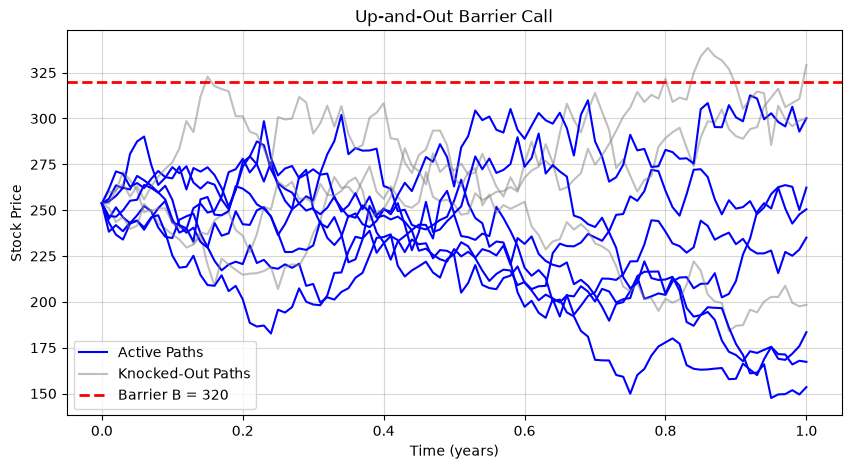

In [14]:
visual_pricer = BarrierMonteCarloPricer(barrier_option, seed=42)

paths, time = visual_pricer.generate_price_paths(num_simulations=10, num_steps=100)

hit = (paths >= barrier).any(axis=0)

plt.figure(figsize=(10, 5))

for i in range(paths.shape[1]):
    if hit[i]:
        plt.plot(time, paths[:, i], color="grey", alpha=0.5, label="Knocked-Out Paths")
    else:
        plt.plot(time, paths[:, i], color="b", label="Active Paths")

plt.axhline(barrier, linestyle="--", linewidth=2, color="r", label=f"Barrier B = {barrier}")

plt.xlabel("Time (years)")
plt.ylabel("Stock Price")
plt.title("Up-and-Out Barrier Call")
plt.grid(alpha=0.5)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys())

plt.show()

The plot shows the paths crossing the barrier are knocked out and receive zero payoff, while paths remaining below the barrier retain the usual call payoff at maturity, illustrating how Monte Carlo simulation captures path-dependent behaviour.